<a href="https://colab.research.google.com/github/NomanAhmed234/PowerCo-Churn-Analysis/blob/main/02_Data_Quality_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 02: Data Quality Assessment



## Objective

Before performing exploratory data analysis or building machine learning models, it is essential to evaluate the quality of the dataset.

Poor data quality can lead to:

- Incorrect business insights
- Poor model performance
- Misleading statistical analysis
- Ineffective feature engineering

The purpose of this notebook is to identify potential quality issues and determine the preprocessing steps required before analysis.



## Business Question

> **"Can this dataset be trusted for business decision-making and machine learning?"**

## 1. Import Required Libraries

Before beginning the data quality assessment, we need to import the Python libraries that will be used throughout the notebook.

These libraries provide functionality for data manipulation, numerical computations, and data visualization.

- **Pandas** is used for loading and manipulating tabular data.
- **NumPy** provides efficient numerical operations.
- **Matplotlib** is used to create visualizations that help identify data quality issues.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt



## 2. Load the Dataset

The first step in the data quality assessment is to load the datasets into pandas DataFrames.

This project uses two datasets:

- **client_data.csv** – Contains customer information, including energy consumption, contract details, forecasts, margins, and the target variable (customer churn).
- **price_data.csv** – Contains historical electricity pricing information for customers.

Loading the datasets allows us to inspect their structure, evaluate data quality, and prepare them for further analysis in the following sections.

In [2]:
client_df = pd.read_csv("client_data.csv")

price_df = pd.read_csv("price_data.csv")

## 3. Dataset Information Review

Before assessing the quality of the data, it is important to inspect the overall structure of both datasets.

This step helps verify that the datasets have been loaded correctly and provides an overview of the available features, data types, and memory usage. Understanding this information is essential for identifying any potential issues that may require preprocessing before further analysis.

In [5]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [6]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


## 4. Data Quality Assessment

Data quality plays a crucial role in building reliable machine learning models. Poor-quality data can lead to inaccurate insights, biased predictions, and reduced model performance.

In this section, we systematically evaluate different aspects of the dataset to ensure it is suitable for exploratory data analysis and machine learning.

### 4.1 Missing Value Analysis

Missing values can affect statistical analysis and machine learning performance. Therefore, the first step in assessing data quality is to determine whether any features contain missing observations.

The following analysis counts the number of missing values in each column of both datasets.

In [7]:
client_df.isnull().sum()

,0
id,0
channel_sales,0
cons_12m,0
cons_gas_12m,0
cons_last_month,0
date_activ,0
date_end,0
date_modif_prod,0
date_renewal,0
forecast_cons_12m,0


In [8]:
price_df.isnull().sum()

,0
id,0
price_date,0
price_off_peak_var,0
price_peak_var,0
price_mid_peak_var,0
price_off_peak_fix,0
price_peak_fix,0
price_mid_peak_fix,0


### 4.2 Duplicate Record Analysis

Duplicate records can distort statistical summaries and introduce bias into machine learning models. This step checks whether any duplicate observations exist in the client and price datasets.

If duplicate records are found, they should be investigated before proceeding with further analysis.

In [ ]:
client_df.duplicated().sum()

In [9]:
price_df.duplicated().sum()

np.int64(0)

### 4.3 Data Type Validation

Each feature should have an appropriate data type based on its business meaning. Incorrect data types can lead to errors during preprocessing and feature engineering.

This analysis reviews the data types of all columns to identify features that may require conversion before model development.

In [10]:
client_df.dtypes

,0
id,object
channel_sales,object
cons_12m,int64
cons_gas_12m,int64
cons_last_month,int64
date_activ,object
date_end,object
date_modif_prod,object
date_renewal,object
forecast_cons_12m,float64


### 4.4 Date Consistency Validation

Date variables are important for understanding customer behavior over time. Before using them for feature engineering, they should be converted into the appropriate datetime format.

This section also validates whether the dates follow logical business rules, such as ensuring that activation dates occur before contract end dates.

In [3]:
date_columns=[
"date_activ",
"date_end",
"date_modif_prod",
"date_renewal"
]

client_df[date_columns]=client_df[date_columns].apply(pd.to_datetime)

In [7]:
price_df["price_date"]=price_df["price_date"].apply(pd.to_datetime)

In [4]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              14606 non-null  object        
 1   channel_sales                   14606 non-null  object        
 2   cons_12m                        14606 non-null  int64         
 3   cons_gas_12m                    14606 non-null  int64         
 4   cons_last_month                 14606 non-null  int64         
 5   date_activ                      14606 non-null  datetime64[ns]
 6   date_end                        14606 non-null  datetime64[ns]
 7   date_modif_prod                 14606 non-null  datetime64[ns]
 8   date_renewal                    14606 non-null  datetime64[ns]
 9   forecast_cons_12m               14606 non-null  float64       
 10  forecast_cons_year              14606 non-null  int64         
 11  fo

In [8]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  193002 non-null  object        
 1   price_date          193002 non-null  datetime64[ns]
 2   price_off_peak_var  193002 non-null  float64       
 3   price_peak_var      193002 non-null  float64       
 4   price_mid_peak_var  193002 non-null  float64       
 5   price_off_peak_fix  193002 non-null  float64       
 6   price_peak_fix      193002 non-null  float64       
 7   price_mid_peak_fix  193002 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 11.8+ MB


In [9]:
(client_df["date_activ"]>client_df["date_end"]).sum()

np.int64(0)

### 4.5 Unique Identifier Validation

Each customer should have a unique identifier. Duplicate customer IDs may indicate data integrity issues that could negatively impact analysis and model performance.

This step verifies that every customer ID appears only once in the dataset.

In [10]:
client_df["id"].nunique()

len(client_df)

14606

In [11]:
price_df["id"].nunique()

len(price_df)

193002

### 4.6 Constant Feature Detection

A constant feature contains only a single unique value across all observations. Since such features provide no useful information for distinguishing between customers, they do not contribute to predictive modeling.

This analysis identifies any constant features present in the dataset.

In [12]:
constant=[]

for col in client_df.columns:
    if client_df[col].nunique()==1:
        constant.append(col)

constant

[]

In [13]:
constant=[]

for col in price_df.columns:
    if price_df[col].nunique()==1:
        constant.append(col)

constant

[]

### 4.7 Near-Constant Feature Analysis

Near-constant features contain one dominant value for the vast majority of observations. Although they are not entirely constant, they often provide very little predictive information.

This analysis helps identify features where a single value accounts for most of the dataset.

In [14]:
for col in client_df.columns:

    print(client_df[col].value_counts(normalize=True).head(1))

id
563dde550fd624d7352f3de77c0cdfcd    0.000068
Name: proportion, dtype: float64
channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    0.462413
Name: proportion, dtype: float64
cons_12m
0    0.00801
Name: proportion, dtype: float64
cons_gas_12m
0    0.821169
Name: proportion, dtype: float64
cons_last_month
0    0.341161
Name: proportion, dtype: float64
date_activ
2009-08-01    0.006504
Name: proportion, dtype: float64
date_end
2016-02-01    0.009927
Name: proportion, dtype: float64
date_modif_prod
2015-11-01    0.049363
Name: proportion, dtype: float64
date_renewal
2015-06-23    0.040189
Name: proportion, dtype: float64
forecast_cons_12m
0.0    0.02095
Name: proportion, dtype: float64
forecast_cons_year
0    0.420923
Name: proportion, dtype: float64
forecast_discount_energy
0.0    0.964946
Name: proportion, dtype: float64
forecast_meter_rent_12m
0.0    0.049637
Name: proportion, dtype: float64
forecast_price_energy_off_peak
0.145711    0.063878
Name: proportion, dtype: float64
forecast_pri

### Interpretation

The near-constant feature analysis shows that most features have a reasonably diverse distribution of values. However, a few variables contain one value that dominates a large proportion of the observations.

For example:

- `forecast_discount_energy` has a value of **0.0** for approximately **96.5%** of customers.
- `has_gas` is **'f' (False)** for about **81.8%** of customers.
- `nb_prod_act` has a value of **1** for approximately **78.3%** of customers.
- The target variable `churn` is dominated by the value **0**, representing about **90.3%** of the dataset, indicating a strong class imbalance.

Although these features are highly concentrated around a single value, none of them are completely constant. Therefore, they should not be removed solely based on this analysis.

### Business Interpretation

The results suggest that certain customer characteristics are naturally more common within PowerCo's customer base. For instance, most customers do not receive forecasted energy discounts, the majority do not have gas services, and most customers subscribe to only one active product.

Similarly, the high proportion of non-churned customers reflects a typical business scenario in the energy industry, where customer churn is relatively infrequent compared to customer retention.

These distributions appear to reflect normal business operations rather than data quality issues.

### Machine Learning Interpretation

Near-constant features contribute limited information because they exhibit low variability. While they may still contain useful predictive signals, their overall impact on model performance may be smaller than features with greater variation.

The dominant proportion of the `churn` class also confirms that this is an **imbalanced binary classification problem**. During model development, evaluation metrics such as **Precision, Recall, F1-Score, and ROC-AUC** should be prioritized over accuracy. Depending on the chosen algorithm, techniques such as class weighting or resampling may also be considered.

### Key Takeaway

No completely near-constant features require immediate removal. However, several variables are highly skewed toward a single value, and the target variable is significantly imbalanced. These characteristics should be considered during feature engineering and model evaluation.

### 4.8 Cardinality Analysis

Categorical features can contain different numbers of unique values. Understanding feature cardinality is important because it influences the choice of encoding techniques during preprocessing.

This analysis examines the number of unique categories in each categorical feature.

In [15]:
categorical=client_df.select_dtypes("object").columns

for col in categorical:

    print(col)

    print(client_df[col].nunique())

id
14606
channel_sales
8
has_gas
2
origin_up
6


In [17]:
categorical=price_df.select_dtypes("object").columns

for col in categorical:

    print(col)

    print(price_df[col].nunique())

id
16096


### 4.9 Numerical Feature Validation

Descriptive statistics provide an overview of the numerical features and help identify unusual values, unrealistic ranges, or potential data quality issues.

This step summarizes the distribution of all numerical variables.

In [19]:
price_df.describe().T

,count,mean,min,25%,50%,75%,max,std
price_date,193002,2015-06-16 12:50:49.933161216,2015-01-01 00:00:00,2015-04-01 00:00:00,2015-07-01 00:00:00,2015-10-01 00:00:00,2015-12-01 00:00:00,NaN
price_off_peak_var,193002.0,0.141027,0.0,0.125976,0.146033,0.151635,0.2807,0.025032
price_peak_var,193002.0,0.05463,0.0,0.0,0.085483,0.101673,0.229788,0.049924
price_mid_peak_var,193002.0,0.030496,0.0,0.0,0.0,0.072558,0.114102,0.036298
price_off_peak_fix,193002.0,43.334477,0.0,40.728885,44.26693,44.44471,59.44471,5.410297
price_peak_fix,193002.0,10.622875,0.0,0.0,0.0,24.339581,36.490692,12.841895
price_mid_peak_fix,193002.0,6.409984,0.0,0.0,0.0,16.226389,17.458221,7.773592


In [18]:
client_df.describe().T

,count,mean,min,25%,50%,75%,max,std
cons_12m,14606.0,159220.286252,0.0,5674.75,14115.5,40763.75,6207104.0,573465.264198
cons_gas_12m,14606.0,28092.375325,0.0,0.0,0.0,0.0,4154590.0,162973.059057
cons_last_month,14606.0,16090.269752,0.0,0.0,792.5,3383.0,771203.0,64364.196422
date_activ,14606,2011-01-28 07:54:18.879912448,2003-05-09 00:00:00,2010-01-15 00:00:00,2011-03-04 00:00:00,2012-04-19 00:00:00,2014-09-01 00:00:00,NaN
date_end,14606,2016-07-27 20:48:26.422018560,2016-01-28 00:00:00,2016-04-27 06:00:00,2016-08-01 00:00:00,2016-10-31 00:00:00,2017-06-13 00:00:00,NaN
date_modif_prod,14606,2013-01-02 12:29:10.951663872,2003-05-09 00:00:00,2010-08-12 00:00:00,2013-06-19 00:00:00,2015-06-16 00:00:00,2016-01-29 00:00:00,NaN
date_renewal,14606,2015-07-21 06:59:00.353279488,2013-06-26 00:00:00,2015-04-17 00:00:00,2015-07-27 00:00:00,2015-10-29 00:00:00,2016-01-28 00:00:00,NaN
forecast_cons_12m,14606.0,1868.61488,0.0,494.995,1112.875,2401.79,82902.83,2387.571531
forecast_cons_year,14606.0,1399.762906,0.0,0.0,314.0,1745.75,175375.0,3247.786255
forecast_discount_energy,14606.0,0.966726,0.0,0.0,0.0,0.0,30.0,5.108289


### 4.10 Negative Value Analysis

Certain numerical features, such as energy consumption and power usage, are generally expected to have non-negative values.

This analysis checks whether any numerical variables contain negative values that may require further investigation.

In [21]:
numerical=client_df.select_dtypes(include=np.number)

(numerical<0).sum()

,0
cons_12m,0
cons_gas_12m,0
cons_last_month,0
forecast_cons_12m,0
forecast_cons_year,0
forecast_discount_energy,0
forecast_meter_rent_12m,0
forecast_price_energy_off_peak,0
forecast_price_energy_peak,0
forecast_price_pow_off_peak,0


In [20]:
numerical=price_df.select_dtypes(include=np.number)

(numerical<0).sum()

,0
price_off_peak_var,0
price_peak_var,0
price_mid_peak_var,0
price_off_peak_fix,0
price_peak_fix,0
price_mid_peak_fix,0


### 4.11 Zero Value Analysis

Zero values are not always errors. Depending on the business context, they may represent inactive customers, newly activated accounts, or genuine observations.

This section identifies the number of zero values in each numerical feature to determine whether further investigation is necessary.

In [23]:
for col in numerical:

    print(col)

    print((client_df[col]==0).sum())

cons_12m
117
cons_gas_12m
11994
cons_last_month
4983
forecast_cons_12m
306
forecast_cons_year
6148
forecast_discount_energy
14094
forecast_meter_rent_12m
725
forecast_price_energy_off_peak
22
forecast_price_energy_peak
7021
forecast_price_pow_off_peak
94
imp_cons
6169
margin_gross_pow_ele
157
margin_net_pow_ele
157
nb_prod_act
0
net_margin
185
num_years_antig
0
pow_max
0
churn
13187


### 4.12 Infinite Value Detection

Infinite values can arise from invalid mathematical operations or data processing errors. Machine learning algorithms cannot handle infinite values directly, making it important to verify that none exist in the dataset.

The following analysis checks for positive and negative infinite values.

In [25]:
np.isinf(numerical).sum()

,0
cons_12m,0
cons_gas_12m,0
cons_last_month,0
forecast_cons_12m,0
forecast_cons_year,0
forecast_discount_energy,0
forecast_meter_rent_12m,0
forecast_price_energy_off_peak,0
forecast_price_energy_peak,0
forecast_price_pow_off_peak,0


### 4.13 Initial Outlier Assessment

Outliers are observations that differ substantially from the majority of the data. They are common in real-world datasets and may represent unusual customer behavior rather than data errors.

This section uses boxplots to identify potential outliers. At this stage, the objective is only to detect them. A more detailed outlier analysis will be performed during the Exploratory Data Analysis (EDA) phase.

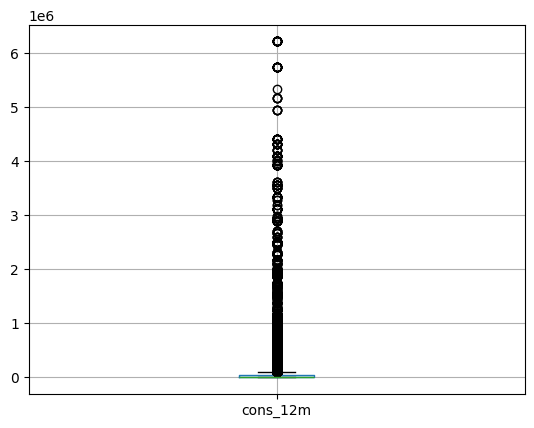

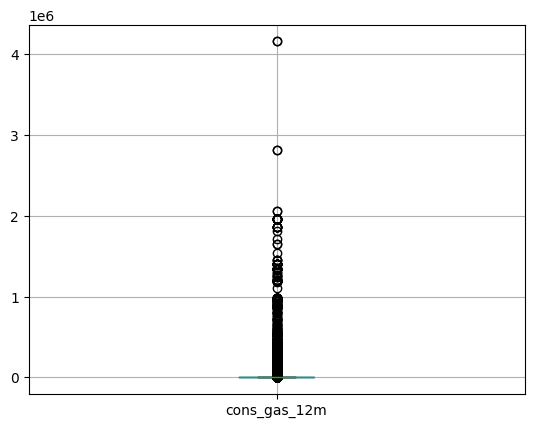

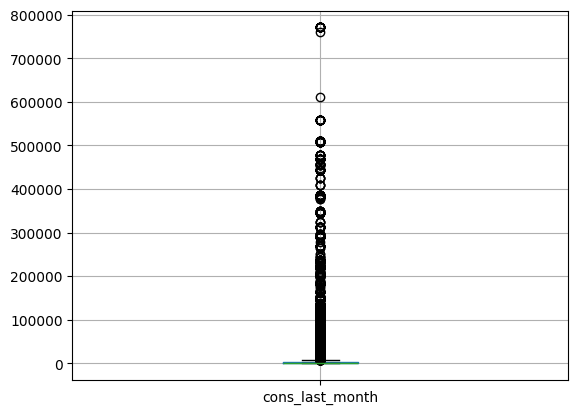

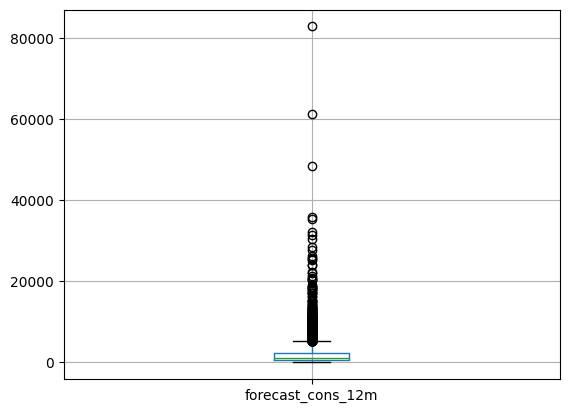

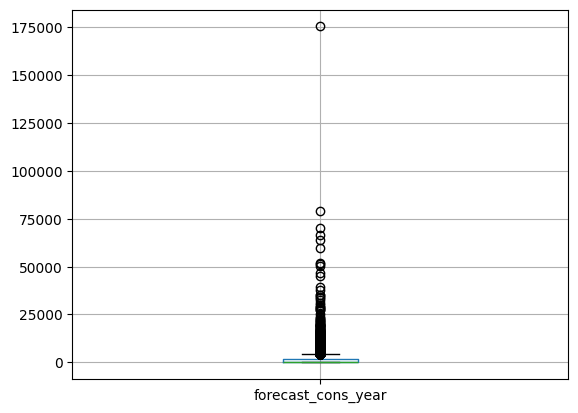

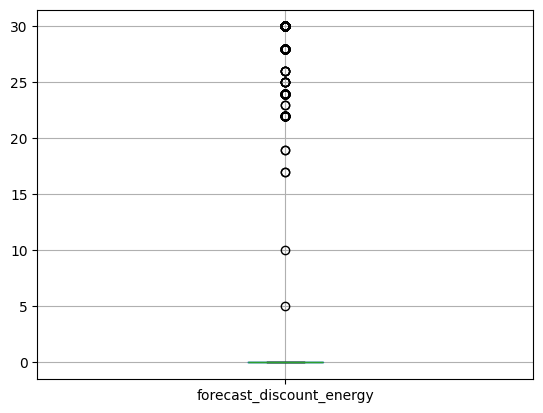

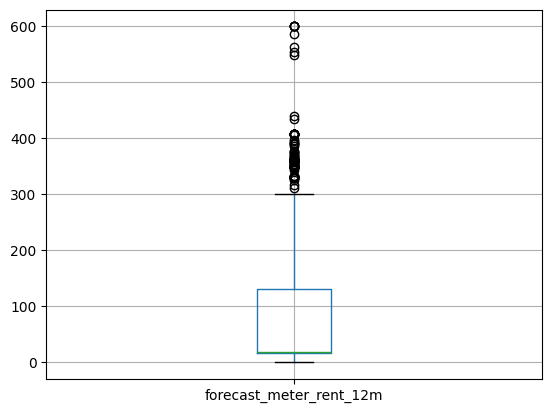

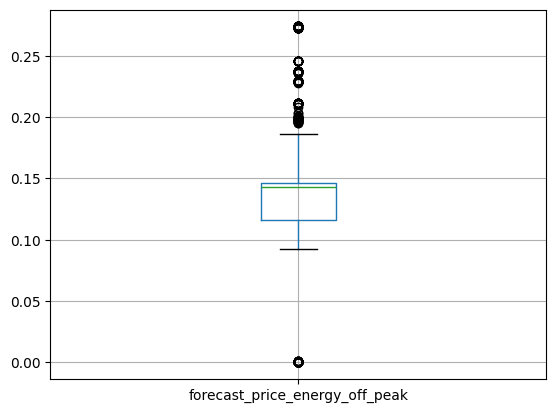

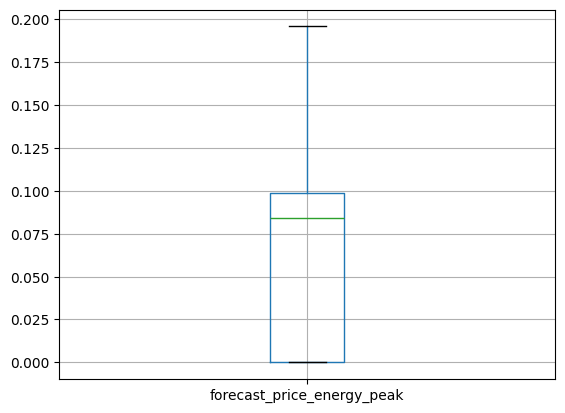

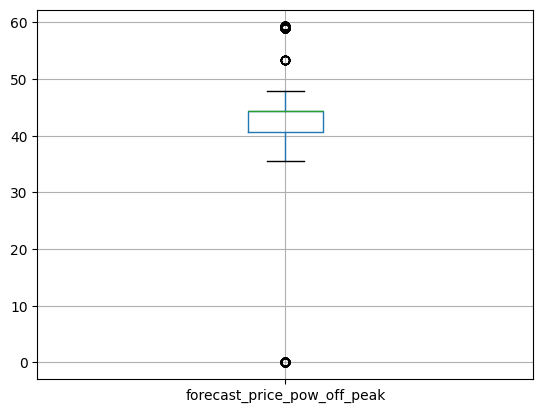

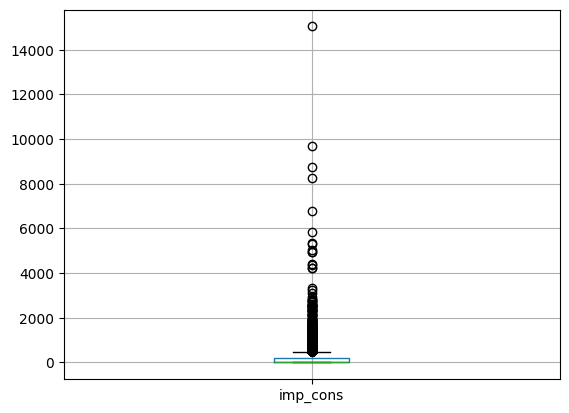

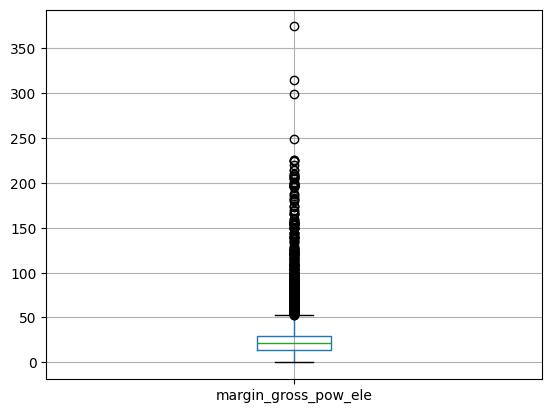

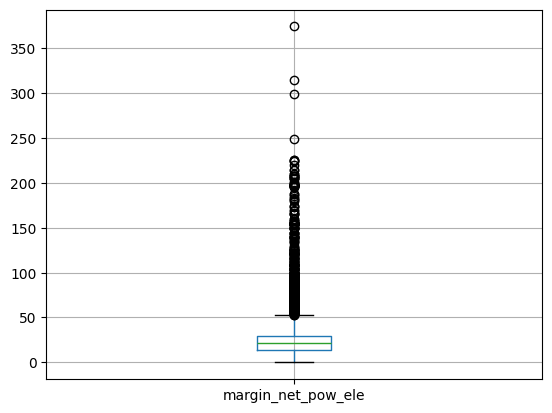

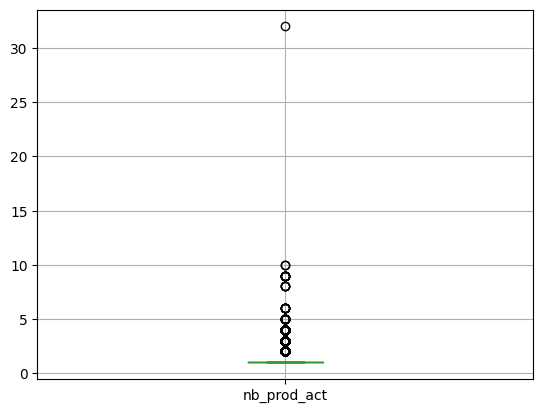

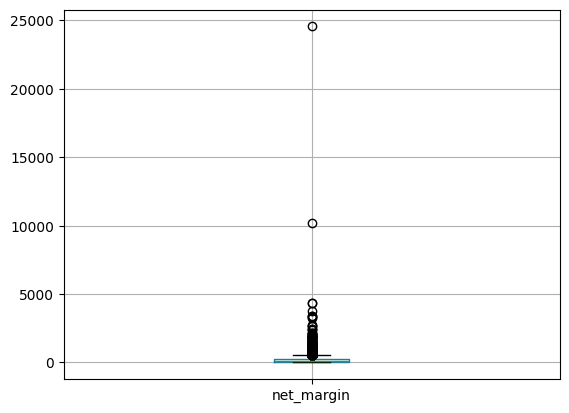

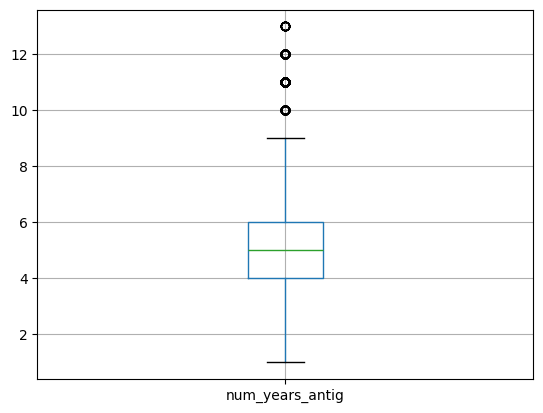

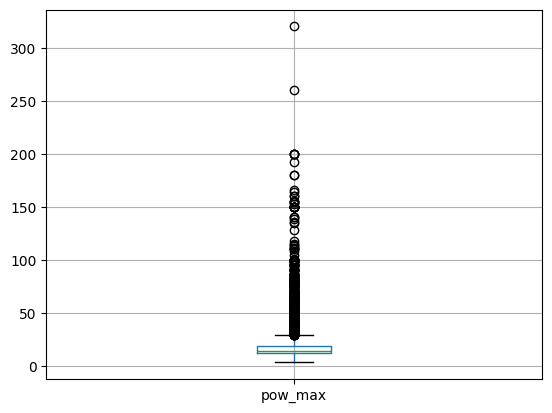

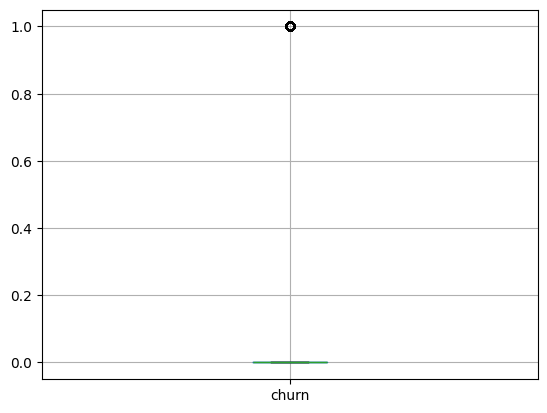

In [26]:
for col in numerical.columns:

    client_df.boxplot(column=col)

    plt.show()

# 5. Notebook Summary

## Executive Summary

In this notebook, we conducted a comprehensive data quality assessment of the PowerCo customer churn dataset to determine whether it is suitable for exploratory data analysis, feature engineering, and machine learning.

The assessment focused on evaluating data completeness, consistency, integrity, and validity across both the client and price datasets.



## Key Findings

### Dataset Completeness

- Both the **client** and **price** datasets contain **no missing values**.
- Every feature is fully populated, indicating a high-quality data collection process.
- No data imputation is required before proceeding to further analysis.



### Duplicate Records

- No duplicate records were found in either dataset.
- Each customer record in the client dataset is unique.
- The price dataset also contains unique observations without redundant entries.

This ensures that statistical summaries and machine learning models will not be biased by duplicated information.



### Data Type Validation

- Numerical variables have appropriate numeric data types.
- Categorical variables are correctly stored as object types.
- Date-related features were successfully converted to the **datetime** format, making them suitable for temporal analysis and feature engineering.



### Data Integrity

Several business rules were validated, including:

- Contract activation dates always occur before contract end dates.
- No invalid date sequences were detected.
- Customer identifiers are unique.
- No constant features were found in either dataset.

These findings indicate strong data integrity and consistency.



### Feature Characteristics

The analysis identified several highly concentrated features, including:

- `forecast_discount_energy`
- `has_gas`
- `nb_prod_act`

Although these variables contain dominant values, they are **not constant** and may still provide useful predictive information.

The target variable (`churn`) is also highly imbalanced, with approximately **90% of customers remaining** and **10% churning**.



### Numerical Validation

The numerical validation revealed that:

- No unexpected negative values were found in numerical variables.
- No infinite values exist in either dataset.
- Several variables contain zero values, which are likely to represent legitimate business scenarios such as inactive consumption or the absence of discounts rather than data quality issues.



### Outlier Assessment

Initial boxplot analysis indicates that several numerical variables contain outliers.

Given the nature of the energy industry, these observations are likely to represent customers with unusually high energy consumption, pricing, or financial margins rather than data entry errors.

At this stage, the outliers have been identified but **not removed**, as they may carry valuable business information.

A more detailed outlier investigation will be performed during the Exploratory Data Analysis phase.



## Overall Conclusion

The overall data quality assessment indicates that the PowerCo customer churn dataset is **clean, complete, and reliable**.

The datasets contain:

- ✅ No missing values
- ✅ No duplicate records
- ✅ No duplicate customer identifiers
- ✅ No invalid date relationships
- ✅ No constant features
- ✅ No unexpected negative values
- ✅ No infinite values

The primary observations from this assessment are:

- Several features exhibit highly concentrated distributions.
- The target variable is significantly imbalanced.
- Numerical variables contain natural outliers that require further investigation but should not be removed without business justification.

Overall, the dataset demonstrates a high level of quality and is well suited for exploratory data analysis and predictive modeling.



## Business Perspective

From a business standpoint, the dataset reflects a well-maintained customer information system.

Customer profiles, contract information, pricing history, and consumption records appear to have been collected consistently and accurately.

The identified characteristics—such as the high proportion of retained customers, customers without gas services, and customers receiving no forecasted discounts—are consistent with expected business operations rather than data quality concerns.

This gives confidence that future analyses and predictive models will be based on reliable information.



## Next Steps

Having confirmed the quality of the dataset, the next phase of the project will focus on understanding the distribution and behavior of individual variables.

The next notebook (**03_Univariate_Analysis.ipynb**) will include:

- Distribution analysis of every numerical feature
- Frequency analysis of categorical variables
- Descriptive statistics
- Skewness assessment
- Outlier analysis
- Feature-level business interpretation
- Visualization of each feature using appropriate statistical plots

This analysis will provide a deeper understanding of each feature individually before exploring relationships between variables in the subsequent notebooks.